# PDB preparation for alpha-galactosidase A



### Sections
[Common part](#common)  
[APO only build](#apo)  
[DGJ only build](#holo-(DGJ))  

This notebook prepares apo and holo systems of α-galactosidase A for MD simulations.

Remember to activate the conda environment with ```conda activate htmd```.
If the required software is not installed yet, please read the README file in this repository.

In [1]:
#IMPORT PACKAGES
from htmd.ui import *
import pandas as pd 
import numpy as np
import os 
from htmd.builder import charmm
from moleculekit.tools.graphalignment import maximalSubstructureAlignment
from acemd.protocols import setup_equilibration
from acemd.protocols import setup_production
import re 


2025-12-16 17:09:51,010 - numexpr.utils - INFO - Note: detected 128 virtual cores but NumExpr set to maximum of 64, check "NUMEXPR_MAX_THREADS" environment variable.
2025-12-16 17:09:51,022 - numexpr.utils - INFO - Note: NumExpr detected 128 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 16.
2025-12-16 17:09:51,022 - numexpr.utils - INFO - NumExpr defaulting to 16 threads.



Please cite HTMD: Doerr et al.(2016)JCTC,12,1845. https://dx.doi.org/10.1021/acs.jctc.6b00049
HTMD Documentation at: https://software.acellera.com/htmd/

New HTMD version (2.5.7) is available. You are currently on (2.5.5).
We recommend you create a new conda environment with the latest HTMD version.
Run: `conda create -n htmd2.5.7 htmd=2.5.7 -c acellera -c conda-forge`




2025-12-16 17:09:54,019 - acemd - WARNING - New ACEMD version (4.0.17) is available. You are currently on (4.0.13). We recommend you create a new conda environment with the latest ACEMD version https://software.acellera.com/acemd/install.html 



Acellera Software Not-for-Profit License Agreement v1.2

The software ("Software") has been developed by the contributing
researchers from Acellera and made available through Acellera for your
internal, non-profit research use.

Acellera allows researchers at your institution to run, display, copy and
modify Software on the following conditions:

1. The Software remains at your institution and is not published, distributed,
   or otherwise transferred or made available to other than institution employees
   and students involved in research under your supervision.

2. You agree to make results generated using Software available to other
   academic researchers for non-profit research purposes. If you wish to obtain
   Software for any commercial purposes, including fee-based service projects, you
   will need to execute a separate licensing agreement with Acellera and pay a
   fee. In that case please contact: info@acellera.com.

3. You retain in Software and any modifications to Soft

In the following cell, you can change your data as needed

In [2]:
parent_folder='prepared_systems' #main folder
molecule_folder = '3s5y' #parent folder for organising different structures
folder = f'{parent_folder}/{molecule_folder}'
#generate multiple states-replicas-subfolders in here

molecule = '../glycosylation/3s5y_reglyco.pdb' #PDB path
#we used the 3GXT model from RCSB.org reglycosylated via glycoshape.org


#IF NO MUTATIONS OR RESNAMES TO REMOVE, LEAVE THE LIST EMPTY.
mutations = [] #resid to mutate. #('resid 215', 'SER'),('resid 301', 'GLN')
resnames_to_remove = []  #'SO4','HOH' , 'NOJ'
#if the molecule is previously processed by glycoshape, water and ions should be already removed


# EQUILIBRATION AND SIMULATION DATA
eq_run = '50 ns' #also in us, ns, ps and fs
eq_temp = 300
minimize = 1000
prod_run = '1 us' #also in us, ns, ps and fs
prod_temp = 300


From here please do **not** change:

In [3]:
# default glycan patches
glycan_patch = ['patch 14BB P2:2 P2:3', 'patch 14BB P3:2 P3:3', 'patch 14BB P4:2 P4:3', 'patch 14BB P5:2 P5:3', 'patch 14BB P6:2 P6:3', 'patch 14BB P7:2 P7:3',
         'patch 14BB P2:3 P2:4', 'patch 14BB P3:3 P3:4', 'patch 14BB P4:3 P4:4', 'patch 14BB P5:3 P5:4', 'patch 14BB P6:3 P6:4', 'patch 14BB P7:3 P7:4',
         'patch 13AB P2:4 P2:6', 'patch 13AB P3:4 P3:6', 'patch 13AB P4:4 P4:6', 'patch 13AB P5:4 P5:6', 'patch 13AB P6:4 P6:6', 'patch 13AB P7:4 P7:6',
         'patch 16AT P2:4 P2:5', 'patch 16AT P3:4 P3:5', 'patch 16AT P4:4 P4:5', 'patch 16AT P5:4 P5:5', 'patch 16AT P6:4 P6:5', 'patch 16AT P7:4 P7:5',
         ] #top/top_all36_carb.rtf

###'patch NGLB P0:139 P2:2', 'patch NGLB P0:192 P3:2', 'patch NGLB P0:215 P4:2','patch NGLB P1:139 P5:2', 'patch NGLB P1:192 P6:2', 'patch NGLB P1:215 P7:2',

gly_resid = [139, 192, 215] #glycosylation site

#correct ligand for Holo str
#to model alternative ligands, replace these files with the corresponding
#CGenFF-parameterized structures for chain A and chain B, keeping the rest
#of the protocol unchanged.
dgj_a = '../DGJ/3s5y/DGJ_A.mol2' #chain A 
dgj_b = '../DGJ/3s5y/DGJ_B.mol2' #chain B

#MAKE FOLDER FOR {MOLECULE}
os.makedirs(folder, exist_ok=True) #check and make

#AMINO ACID CODES FOR CONVERSION (do not change)
aa_3to1 = {'ALA': 'A', 'CYS': 'C', 'ASP': 'D', 'GLU': 'E', 'PHE': 'F', 'GLY': 'G', 
 'HIS': 'H', 'ILE': 'I', 'LYS': 'K', 'LEU': 'L', 'MET': 'M', 'ASN': 'N', 
 'PRO': 'P', 'GLN': 'Q', 'ARG': 'R', 'SER': 'S', 'THR': 'T', 'VAL': 'V', 
 'TRP': 'W', 'TYR': 'Y'} #conversion from 3-letter code to 1-letter code

## Common preparation
[Back to main](#sections) 


**TODO** SPOSTARE IL RIMUOVI PATCH DA QUI.

In [4]:
#read the molecule pdb, remove the unwanted molecules (ions, water and NOJ)
mol = Molecule(molecule)

#REMOVE RESNAMES
print(f'\nRemoving residues: {resnames_to_remove}') #check
original_count = mol.numAtoms
if resnames_to_remove:
    selection = ' or '.join([f'resname {res}' for res in resnames_to_remove]) #build correct selection
    mol.filter(f'not ({selection})') #remove
removed_count = original_count - mol.numAtoms #check
print(f'Removed {removed_count} atoms')
print(f'Remaining atoms: {mol.numAtoms}')

################### QUI C'ERA LA MUTAGENESIS #######

#CREATE DUPLICATE FOR MOL_APO 
mol_apo = mol.copy()
mol_DGJ = mol.copy()




Removing residues: []
Removed 0 atoms
Remaining atoms: 6999


copia (sostituire chain con segid), va aggiunta in DGJ

## APO
[Back to main](#sections) 

In [ ]:
#HANDLE MUTATIONS
proteins_apo=[]

if mutations: # <resid  resid> and <mut resname>
    for mutation in mutations:
        resid_sel, new_res = mutation 
        wt = np.unique(mol_apo.get('resname', resid_sel))
        wt = aa_3to1[wt[0]] 
        num = resid_sel.split(' ')[1]
        mut = aa_3to1[new_res]

        folder_apo = f'../{folder}/apo_{wt}{num}{mut}'
        os.makedirs(folder_apo, exist_ok=True)
        print(f'Storing generated data at {folder_apo}')
        
        #MAKE A COPY OF THE APO TO BE MUTATED
        mol_apo_mut = mol_apo.copy()
        mol_apo_mut.mutateResidue(resid_sel, new_res)

            #a questo punto eliminavo le patches 
            
        proteins_apo.append((f'apo_{wt}{num}{mut}', mol_apo_mut, folder_apo, num)) #tolto colonna segid to remove 


#FOR WILD TYPE
else: #no mutations
    folder_apo = f'../{folder}/apo'
    os.makedirs(folder_apo, exist_ok=True) 
    proteins_apo.append(('apo', mol_apo, folder_apo, None)) #tolto colonna segid to remove 



#COMMON
for label, mol, folder_apo, num in proteins_apo:
    segid_to_remove = [] #in case of mut 
    print(f"\nProcessing system: {label}")

    #SYSTEM PREPARATION AND SEGMENTATION.
    system_apo, data = systemPrepare(mol, pH=7.0, return_details=True, plot_pka=f'{folder_apo}/{molecule_folder}_{label}_pka')
    system_apo = autoSegment(system_apo) #segment system
    
####################GENERAZIONE DELLE PATCHES
    prot = np.unique(system_apo.get('segid', 'protein'))  # protein segment IDs
    glyc = np.unique(system_apo.get('segid', 'resname NAG'))  # glycan segment IDs

    patch_data = {}
    for p in prot:
        for r in gly_resid:
            for g in glyc:
                #being so strict selection-wise if there is no ASN no patch is generated
                pair = system_apo.atomselect(f'segid {g} and resname NAG and name C1 and within 5 of (segid {p} and resid {r} and name ND2)',indexes=True)
                patch_data[(p, r, g)] = pair
    filtered = {k: v for k, v in patch_data.items() if v.size > 0} #remove the non matches

    #in case of mutation of the glycosilation site find the segid to be removed
    glyc_in_patches = {g for (_, _, g) in filtered.keys()}
    glyc_all = list(glyc)
    glyc_not_patched = [g for g in glyc_all if g not in glyc_in_patches]

    print('REMOVING THE FOLLOWING GLYCANS, THE GLYCOSILATION SITE IS MUTATED:', glyc_not_patched)
    print(glyc_all)

    patch_list = []
    for (p, r, g), pair in filtered.items():
        patch_str = f"patch NGLB {p}:{r} {g}:2" #protein - glycan patch (the others are fixed) 
        patch_list.append(patch_str)

    patch = patch_list + glycan_patch #as required by htmd
#####################
    print('PATCHES', patch)

####parte due di remodeling: mutazioni e rimozioni pathces 
    if num is not None: #col non empty not wt
        if int(num) in gly_resid:
            print(f'MUTATION IN GLYCOSILATION SITE:{num}')
            glyc_not_patched = list(glyc_not_patched)   
            segid_to_remove.extend(glyc_not_patched)       
            new_patch=[]
            for p in patch:
                parts = p.split()
                segids_in_patch = [part.split(':')[0] for part in parts[2:]]
                
                if any(s in glyc_not_patched for s in segids_in_patch):
                    print(f'REMOVING PATCH (glycan removed): {p}')
                    continue
                new_patch.append(p)
            patch = new_patch

    #######
 
    #remove segid of glycans if in mutation site
    if segid_to_remove:
        sel = ' or '.join([f'segid {sgd}' for sgd in segid_to_remove])
        system_apo.filter(f'not ({sel})')
        print(f"REMOVED GLYCANS AT: {sel}")

    #intermediate saving (non mandatory)
    data.to_csv(f'{folder_apo}/{molecule_folder}_{label}_prep.csv') #save
    system_apo.write(f'{folder_apo}/{molecule_folder}_{label}_prep.pdb') #save

    segments_apo = np.unique(system_apo.segid) #check
    print(f'Segments: {segments_apo}')

    #SYSTEM SOLVATION
    system_solv_apo = solvate(system_apo, negx = 20  , negy = 20, negz = 20, posx = 20, posy = 20, posz = 20)
    system_solv_apo.write(f'{folder_apo}/{molecule_folder}_{label}_solv.pdb')
    #system_solv.write(f'{folder_apo}/{molecule}_solv.psf') #non giusto

    #SYSTEM BUILDING WITH CHARMM36 AND PATCHES
    #other parameters available
    system_charmm_apo = charmm.build(system_solv_apo,  saltconc = 0.15, saltanion = 'CL', saltcation = 'K',
                                topo= ['top/top_all36_prot.rtf', 'top/top_all36_carb.rtf', 'top/top_water_ions.rtf', 'top/top_all36_cgenff.rtf', '../DGJ/top_DGJ.rtf'],    
                                param=['par/par_all36m_prot.prm','par/par_all36_carb.prm','par/par_water_ions.prm', 'par/par_all36_cgenff.prm', '../DGJ/par_DGJ.prm'],
                                stream=['str/carb/toppar_all36_carb_glycopeptide.str'],
                                patches = patch,  
                                outdir = f'{folder_apo}/build') #patches = patch,

#MINIMIZATION AND EQUILIBRATION PREPARATION
setup_equilibration(builddir=f'{folder_apo}/build', 
                        outdir=f'{folder_apo}/equilibration',
                        run = eq_run, #also in us, ns, ps and fs
                        temperature = eq_temp,
                        coordinates = f'{folder_apo}/build/structure.pdb',
                        structure = f'{folder_apo}/build/structure.psf',
                        parameters = f'{folder_apo}/build/parameters.prm',
                        minimize = minimize)


#to remember:
# "NA","MG","ZN","K","CS","CA","CL"  
#, 'noj/noj_g.rtf'
#charmm.listFiles()  #check for files  
# 


#### The **production** folder can be generated only **after the production is compleded**.

In particular:

1. check production ended with *check_end.py* 
2. run *production_prep.py*

## HOLO (DGJ)
[Back to main](#sections) 


Processing system: DGJ

---- Molecule chain report ----
Chain A:
    First residue: LEU    32  
    Final residue: MET   421  
Chain B:
    First residue: LEU    32  
    Final residue: GLN   422  
Chain C:
    First residue: NAG     2  
    Final residue: MAN     6  
Chain D:
    First residue: NAG     2  
    Final residue: MAN     6  
Chain E:
    First residue: NAG     2  
    Final residue: MAN     6  
Chain F:
    First residue: NAG     2  
    Final residue: MAN     6  
Chain G:
    First residue: NAG     2  
    Final residue: MAN     6  
Chain H:
    First residue: NAG     2  
    Final residue: MAN     6  
Chain L:
    First residue: DGJ     1  
    Final residue: DGJ     2  
---- End of chain report ----



2025-12-16 17:11:02,212 - moleculekit.tools.preparation - WARNING - The following residues have not been optimized: MAN, NAG, DGJ
2025-12-16 17:11:02,906 - moleculekit.tools.preparation - INFO - Modified residue HIS    46 A to HIE
2025-12-16 17:11:02,907 - moleculekit.tools.preparation - INFO - Modified residue GLU    48 A to GLH
2025-12-16 17:11:02,908 - moleculekit.tools.preparation - INFO - Modified residue CYS    52 A to CYX
2025-12-16 17:11:02,908 - moleculekit.tools.preparation - INFO - Modified residue CYS    56 A to CYX
2025-12-16 17:11:02,908 - moleculekit.tools.preparation - INFO - Modified residue CYS    63 A to CYX
2025-12-16 17:11:02,909 - moleculekit.tools.preparation - INFO - Modified residue CYS    94 A to CYX
2025-12-16 17:11:02,909 - moleculekit.tools.preparation - INFO - Modified residue HIS   115 A to HIP
2025-12-16 17:11:02,910 - moleculekit.tools.preparation - INFO - Modified residue HIS   125 A to HIE
2025-12-16 17:11:02,910 - moleculekit.tools.preparation - INFO

P0 139 P2 [12247]
P0 139 P3 []
P0 139 P4 []
P0 139 P5 []
P0 139 P6 []
P0 139 P7 []
P0 192 P2 []
P0 192 P3 []
P0 192 P4 [12483]
P0 192 P5 []
P0 192 P6 []
P0 192 P7 []
P0 215 P2 []
P0 215 P3 []
P0 215 P4 []
P0 215 P5 []
P0 215 P6 [12719]
P0 215 P7 []
P1 139 P2 []
P1 139 P3 [12365]
P1 139 P4 []
P1 139 P5 []
P1 139 P6 []
P1 139 P7 []
P1 192 P2 []
P1 192 P3 []
P1 192 P4 []
P1 192 P5 [12601]
P1 192 P6 []
P1 192 P7 []
P1 215 P2 []
P1 215 P3 []
P1 215 P4 []
P1 215 P5 []
P1 215 P6 []
P1 215 P7 [12837]
REMOVING THE FOLLOWING GLYCANS, THE GLYCOSILATION SITE IS MUTATED: []
['P2', 'P3', 'P4', 'P5', 'P6', 'P7']
Segments: ['P0' 'P1' 'P2' 'P3' 'P4' 'P5' 'P6' 'P7' 'P8']


2025-12-16 17:11:10,604 - htmd.builder.solvate - INFO - Using water pdb file at: /leonardo/home/userexternal/icazzani/miniconda3/envs/htmd/lib/python3.10/site-packages/htmd/share/solvate/wat.pdb
2025-12-16 17:11:11,152 - htmd.builder.solvate - INFO - Replicating 18 water segments, 3 by 3 by 2
Solvating: 100%|██████████| 18/18 [00:07<00:00,  2.37it/s]
2025-12-16 17:11:24,852 - htmd.builder.solvate - INFO - 60552 water molecules were added to the system.
2025-12-16 17:11:25,040 - moleculekit.writers - WARNING - Field "serial" of PDB overflows. Your data will be truncated to 5 characters.
2025-12-16 17:11:32,260 - htmd.builder.charmm - INFO - Writing out segments.
2025-12-16 17:11:43,468 - moleculekit.writers - WARNING - Field "serial" of PDB overflows. Your data will be truncated to 5 characters.
2025-12-16 17:11:44,099 - moleculekit.writers - WARNING - Field "serial" of PDB overflows. Your data will be truncated to 5 characters.
2025-12-16 17:11:44,951 - moleculekit.writers - WARNING - 

Disulfide Bond between: UniqueResidueID<resname: 'CYX', chain: 'B', resid: 56, insertion: '', segid: 'P1'>
                   and: UniqueResidueID<resname: 'CYX', chain: 'B', resid: 63, insertion: '', segid: 'P1'>

Disulfide Bond between: UniqueResidueID<resname: 'CYX', chain: 'A', resid: 56, insertion: '', segid: 'P0'>
                   and: UniqueResidueID<resname: 'CYX', chain: 'A', resid: 63, insertion: '', segid: 'P0'>

Disulfide Bond between: UniqueResidueID<resname: 'CYX', chain: 'A', resid: 52, insertion: '', segid: 'P0'>
                   and: UniqueResidueID<resname: 'CYX', chain: 'A', resid: 94, insertion: '', segid: 'P0'>

Disulfide Bond between: UniqueResidueID<resname: 'CYX', chain: 'A', resid: 378, insertion: '', segid: 'P0'>
                   and: UniqueResidueID<resname: 'CYX', chain: 'A', resid: 382, insertion: '', segid: 'P0'>

Disulfide Bond between: UniqueResidueID<resname: 'CYX', chain: 'B', resid: 52, insertion: '', segid: 'P1'>
                   and: UniqueR

2025-12-16 17:11:51,347 - htmd.builder.charmm - INFO - Starting the build.
2025-12-16 17:11:52,491 - htmd.builder.charmm - WARNING - Failed to set coordinates for 216 atoms.
2025-12-16 17:11:52,498 - htmd.builder.charmm - WARNING - Failed to guess coordinates for 9 atoms due to bad angles.
2025-12-16 17:11:52,498 - htmd.builder.charmm - WARNING - Poorly guessed coordinates for 68 atoms.
2025-12-16 17:11:52,499 - htmd.builder.charmm - WARNING - Please check /leonardo_work/IscrC_aGAL1/aGAL/prepared_systems/3s5y/DGJ/build/log.txt for further information.
2025-12-16 17:11:52,500 - htmd.builder.charmm - INFO - Finished building.
2025-12-16 17:11:54,718 - moleculekit.readers - WARNING - Non-integer values were read from the PDB "serial" field. Dropping PDB values and assigning new ones.
2025-12-16 17:11:54,815 - moleculekit.readers - WARNING - Reading PDB file with more than 99999 atoms. Bond information can be wrong.
2025-12-16 17:12:00,793 - htmd.builder.ionize - INFO - Adding 0 anions + 1

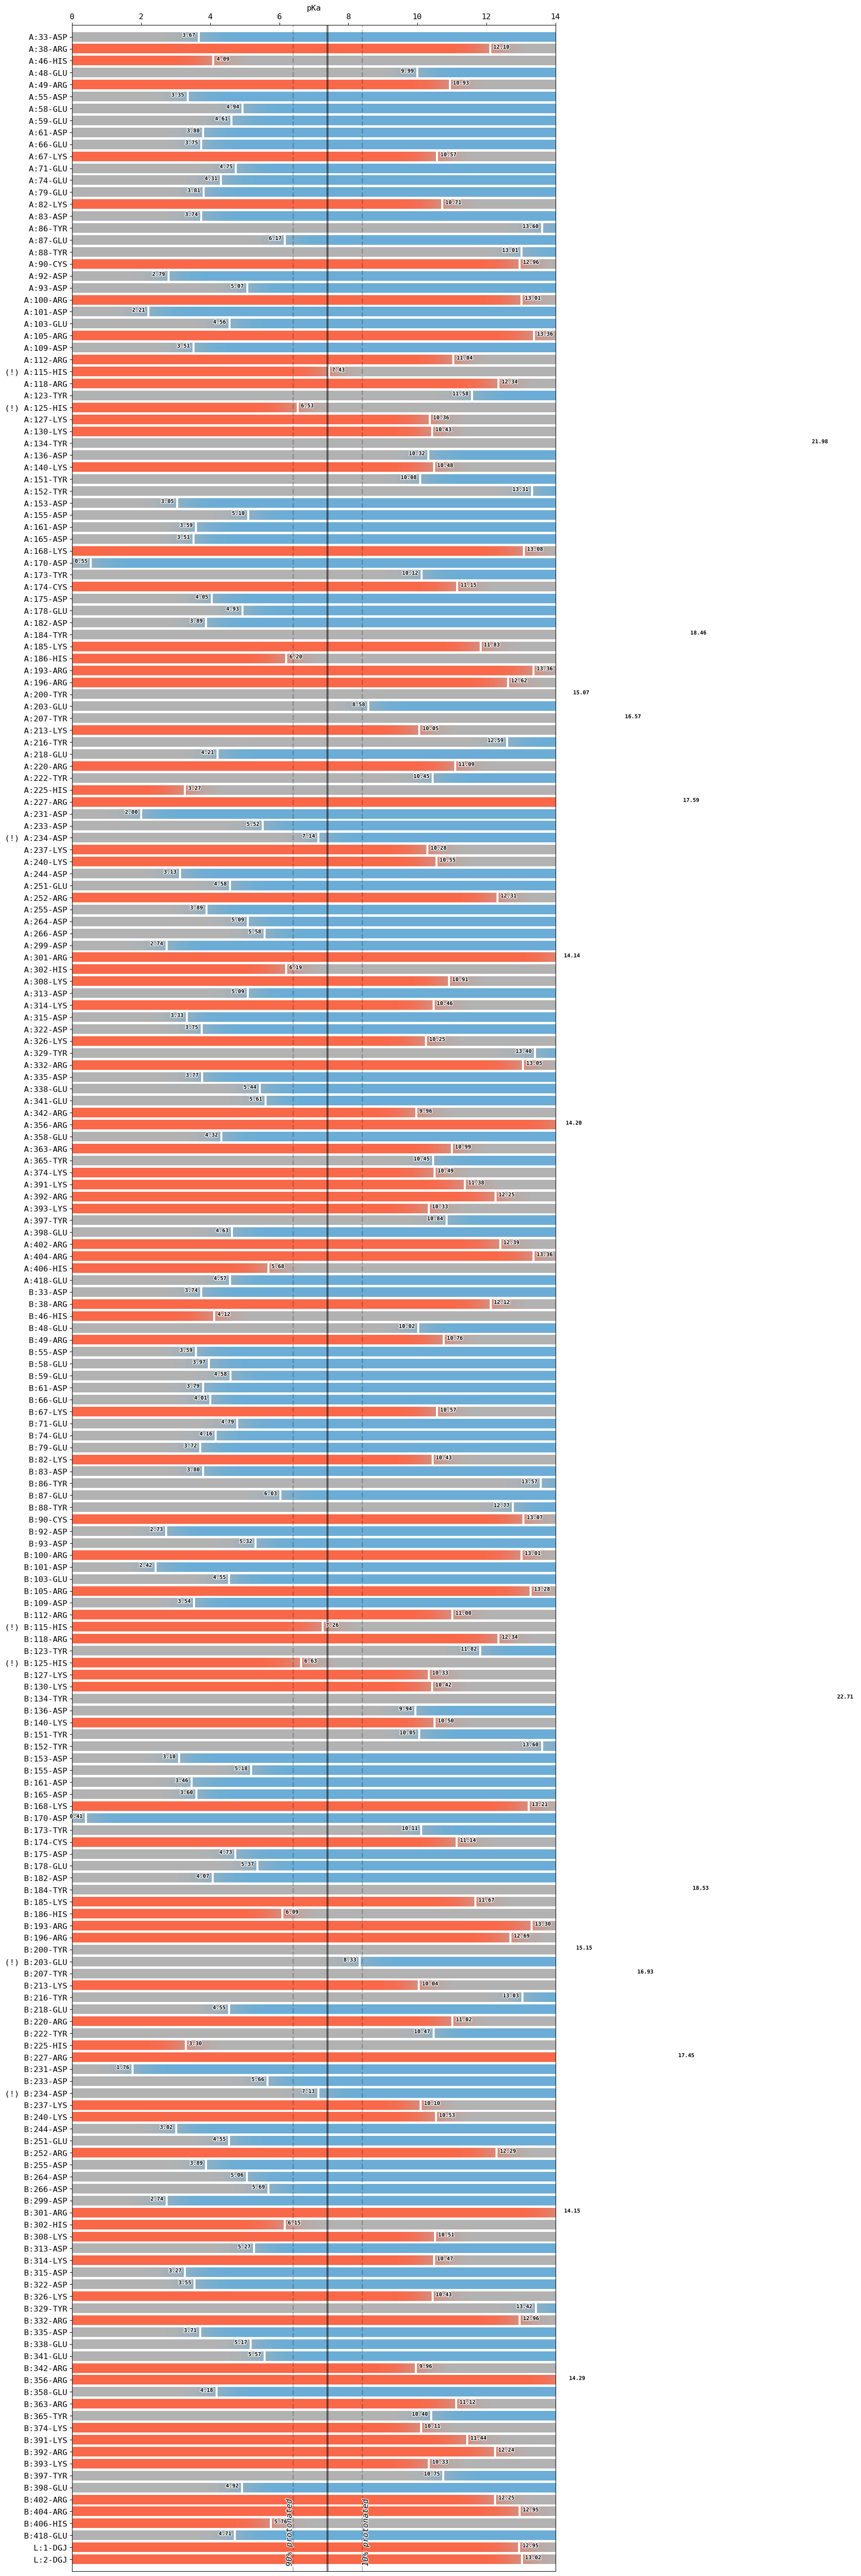

In [6]:
#HANDLE MUTATIONS
proteins_DGJ=[]

if mutations: # <resid  resid> and <mut resname>
    for mutation in mutations:
        resid_sel, new_res = mutation 
        wt = np.unique(mol_DGJ.get('resname', resid_sel))
        wt = aa_3to1[wt[0]] 
        num = resid_sel.split(' ')[1]
        mut = aa_3to1[new_res]

        folder_DGJ = f'../{folder}/DGJ_{wt}{num}{mut}'
        os.makedirs(folder_DGJ, exist_ok=True)
        print(f'Storing generated data at {folder_DGJ}')
        
        #MAKE A COPY OF THE APO TO BE MUTATED
        mol_DGJ_mut = mol_DGJ.copy()
        mol_DGJ_mut.mutateResidue(resid_sel, new_res)

            #a questo punto eliminavo le patches 
            
        proteins_DGJ.append((f'DGJ_{wt}{num}{mut}', mol_DGJ_mut, folder_DGJ, num)) #tolto colonna segid to remove 

#FOR WILD TYPE
else: #no mutations
    folder_DGJ = f'../{folder}/DGJ'
    os.makedirs(folder_DGJ, exist_ok=True) 
    proteins_DGJ.append(('DGJ', mol_DGJ, folder_DGJ, None)) #tolto colonna segid to remove 



#COMMON
for label, mol, folder_DGJ, num in proteins_DGJ: 
    segid_to_remove = [] # in case of mut
    print(f"\nProcessing system: {label}")

    #APPEND CORRECT DGJ IN CHAIN A AND B
    #chain A
    DGJ_A = Molecule(dgj_a)
    DGJ_A.set('resid', '1', 'resname DGJ')
    DGJ_A.set('chain', 'L', 'resname DGJ')
    #chain B
    DGJ_B = Molecule(dgj_b)
    DGJ_B.set('resid', '2', 'resname DGJ')
    DGJ_B.set('chain', 'L', 'resname DGJ')
    #append
    mol.append(DGJ_A)
    mol.append(DGJ_B)

    #SYSTEM PREPARATION AND SEGMENTATION.
    system_DGJ, data = systemPrepare(mol, pH=7.0, return_details=True, plot_pka=f'{folder_DGJ}/_{folder}_{label}_pka')
    system_DGJ = autoSegment(system_DGJ) #segment system

####################GENERAZIONE DELLE PATCHES
    prot = np.unique(system_DGJ.get('segid', 'protein'))  # protein segment IDs
    glyc = np.unique(system_DGJ.get('segid', 'resname NAG'))  # glycan segment IDs    

    patch_data = {}
    for p in prot:
        for r in gly_resid:
            for g in glyc:
                #being so strict selection-wise if there is no ASN no patch is generated
                pair = system_DGJ.atomselect(f'segid {g} and resname NAG and name C1 and within 5 of (segid {p} and resid {r} and name ND2)',indexes=True)
                patch_data[(p, r, g)] = pair
                print(p, r, g, pair)
    filtered = {k: v for k, v in patch_data.items() if v.size > 0} #remove non-matched cases


    #in case of mutation of the glycosilation site find the segit to be removed
    glyc_in_patches = {g for (_, _, g) in filtered.keys()}
    glyc_all = list(glyc)
    glyc_not_patched = [g for g in glyc_all if g not in glyc_in_patches]

    print('REMOVING THE FOLLOWING GLYCANS, THE GLYCOSILATION SITE IS MUTATED:', glyc_not_patched)
    print(glyc_all)               

    patch_list = []
    for (p, r, g), pair in filtered.items():
        patch_str = f'patch NGLB {p}:{r} {g}:2' #protein - glycan patch (the others are fixed)
        patch_list.append(patch_str)

    patch = patch_list + glycan_patch 
    
    #patch removal in case of mutation on the glycosylated site
    if num is not None: #col not empty (not wt)
        if int(num) in gly_resid:
            print(f'MUTATION IN GLYCOSILATION SITE:{num}')
            glyc_not_patched = list(glyc_not_patched)   
            segid_to_remove.extend(glyc_not_patched)       
            new_patch=[]
            for p in patch:
                parts = p.split()
                segids_in_patch = [part.split(':')[0] for part in parts[2:]]
                
                if any(s in glyc_not_patched for s in segids_in_patch):
                    print(f'REMOVING PATCH (glycan removed): {p}')
                    continue
                new_patch.append(p)
            patch = new_patch


    #remove segid of glycans in mutation site
    if segid_to_remove:
        sel = ' or '.join([f'segid {sgd}' for sgd in segid_to_remove])
        system_DGJ.filter(f'not ({sel})')
        print(f"REMOVED GLYCANS AT: {sel}")

    #intermediate saving
    data.to_csv(f'{folder_DGJ}/{molecule_folder}_{label}_prep.csv') #save
    system_DGJ.write(f'{folder_DGJ}/{molecule_folder}_{label}_prep.pdb') #save

    segments_DGJ = np.unique(system_DGJ.segid) #check
    print(f'Segments: {segments_DGJ}')

    #SYSTEM SOLVATION
    system_solv_DGJ = solvate(system_DGJ, negx = 20  , negy = 20, negz = 20, posx = 20, posy = 20, posz = 20)
    system_solv_DGJ.write(f'{folder_DGJ}/{molecule_folder}_{label}_solv.pdb')
    #system_solv.write(f'../{folder}/_solv.psf') #non giusto

    #SYSTEM BUILDING WITH CHARMM36 AND PATCHES
    #other parameters available
    system_charmm_DGJ = charmm.build(system_solv_DGJ,  saltconc = 0.15, saltanion = 'CL', saltcation = 'K',
                                topo= ['top/top_all36_prot.rtf', 'top/top_all36_carb.rtf', 'top/top_water_ions.rtf', 'top/top_all36_cgenff.rtf', '../DGJ/top_DGJ.rtf'],    
                                param=['par/par_all36m_prot.prm','par/par_all36_carb.prm','par/par_water_ions.prm', 'par/par_all36_cgenff.prm', '../DGJ/par_DGJ.prm'],
                                stream=['str/carb/toppar_all36_carb_glycopeptide.str'],
                                patches = patch,
                                outdir = f'{folder_DGJ}/build') 

    #to remember:
    # "NA","MG","ZN","K","CS","CA","CL'  
    #, 'noj/noj_g.rtf'
    #charmm.listFiles()  #check for files                          

    #MINIMIZATION AND EQUILIBRATION PREPARATION
    setup_equilibration(builddir=f'{folder_DGJ}/build', 
                        outdir=f'{folder_DGJ}/equilibration',
                        run = eq_run, 
                        temperature = eq_temp,
                        coordinates = f'{folder_DGJ}/build/structure.pdb',
                        structure = f'{folder_DGJ}/build/structure.psf',
                        parameters = f'{folder_DGJ}/build/parameters.prm',
                        minimize = minimize)


#### The **production** folder can be generated only **after the production is compleded**.

In particular:

1. check production ended with *check_end.py* 
2. run *production_prep.py*